In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import cv2
from PIL import Image, ImageEnhance, ImageFilter
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.transforms import v2
import math
import torchvision.transforms.functional as TF
import torch.nn.functional as F



In [2]:
from torchinfo import summary



In [3]:
possible_base_dirs = [
    "/kaggle/input/denoising-dirty-documents",
    "/kaggle/working/denoising-dirty-documents",
    "/content/denoising_data",
]

base_dir = next((p for p in possible_base_dirs if os.path.isdir(p)), None)
if base_dir is None:
    raise FileNotFoundError("Unable to locate the dataset directory.")

train_dir = os.path.join(base_dir, "train")
train_cleaned_dir = os.path.join(base_dir, "train_cleaned")
test_dir = os.path.join(base_dir, "test")

print(f"Using dataset root: {base_dir}")
print(f"train_dir: {train_dir}")
print(f"train_cleaned_dir: {train_cleaned_dir}")
print(f"test_dir: {test_dir}")




Using dataset root: /kaggle/input/denoising-dirty-documents
train_dir: /kaggle/input/denoising-dirty-documents/train
train_cleaned_dir: /kaggle/input/denoising-dirty-documents/train_cleaned
test_dir: /kaggle/input/denoising-dirty-documents/test


In [4]:
def get_image_sizes(folder):
    sizes = []
    for filename in sorted(os.listdir(folder)):
        if filename.endswith(".png"):
            img_path = os.path.join(folder, filename)
            with Image.open(img_path) as img:
                w, h = img.size
                sizes.append((h, w))  # (height, width)
    return sizes




In [5]:
train_sizes = get_image_sizes(train_dir)
train_cleaned_sizes = get_image_sizes(train_cleaned_dir)
test_sizes = get_image_sizes(test_dir)



In [6]:
print(f"train_images: {len(train_sizes)}")
print(f"train_cleaned_images: {len(train_cleaned_sizes)}")
print(f"test_images: {len(test_sizes)}")



train_images: 115
train_cleaned_images: 115
test_images: 29


In [7]:
unique_train_sizes = np.unique(train_sizes, axis=0)
unique_train_cleaned_sizes = np.unique(train_cleaned_sizes, axis=0)
unique_test_sizes = np.unique(test_sizes, axis=0)



In [8]:
print(f"train_images:\n {unique_train_sizes}")
print(f"train_cleaned_images:\n {unique_train_cleaned_sizes}")
print(f"test_images:\n {unique_test_sizes}")




train_images:
 [[258 540]
 [420 540]]
train_cleaned_images:
 [[258 540]
 [420 540]]
test_images:
 [[258 540]
 [420 540]]


In [9]:
class PadToSize:
    def __init__(self, target_size):
        self.target_size = target_size  # (height, width)

    def __call__(self, img):
        _, height, width = img.shape
        target_height, target_width = self.target_size

        pad_top = (target_height - height) // 2
        pad_bottom = target_height - height - pad_top
        pad_left = (target_width - width) // 2
        pad_right = target_width - width - pad_left

        return TF.pad(img, [pad_left, pad_top, pad_right, pad_bottom], fill=0)




In [10]:
class Grayscale:
    def __call__(self, img):
        pil_img = TF.to_pil_image(img) if isinstance(img, torch.Tensor) else img
        grayscale_img = pil_img.convert("L")  # RGB -> Grayscale
        return TF.to_tensor(grayscale_img)




In [11]:
train_transforms = v2.Compose(
    [
        v2.ToImage(),
        PadToSize((420, 540)),  # unify size
        v2.RandomApply([v2.GaussianBlur(kernel_size=3)], p=0.4),
        v2.RandomApply([v2.ColorJitter(brightness=0.3, contrast=0.3)], p=0.5),
        Grayscale(),
        v2.ToDtype(torch.float32, scale=True),
    ]
)

val_transforms = v2.Compose(
    [
        v2.ToImage(),
        PadToSize((420, 540)),
        Grayscale(),
        v2.ToDtype(torch.float32, scale=True),
    ]
)

test_transforms = v2.Compose(
    [
        v2.ToImage(),
        PadToSize((420, 540)),
        Grayscale(),
        v2.ToDtype(torch.float32, scale=True),
    ]
)




In [12]:
class ImageDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.image_files = sorted(
            [
                os.path.join(data_dir, f)
                for f in os.listdir(data_dir)
                if f.endswith(".png")
            ],
            key=lambda x: int(os.path.splitext(os.path.basename(x))[0]),
        )  # numeric sort to match submission order

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image




In [13]:
train_files = sorted(
    [os.path.join(train_dir, f) for f in os.listdir(train_dir) if f.endswith(".png")],
    key=lambda x: int(os.path.splitext(os.path.basename(x))[0]),
)
cleaned_files = sorted(
    [
        os.path.join(train_cleaned_dir, f)
        for f in os.listdir(train_cleaned_dir)
        if f.endswith(".png")
    ],
    key=lambda x: int(os.path.splitext(os.path.basename(x))[0]),
)

train_files, val_files, cleaned_train, cleaned_val = train_test_split(
    train_files, cleaned_files, test_size=2 / 9, random_state=42
)




In [14]:
class PairedImageDataset(Dataset):
    def __init__(self, train_files, cleaned_files, transform=None):
        self.train_files = train_files
        self.cleaned_files = cleaned_files
        self.transform = transform

    def __len__(self):
        return len(self.train_files)

    def __getitem__(self, idx):
        train_img = Image.open(self.train_files[idx]).convert("RGB")
        cleaned_img = Image.open(self.cleaned_files[idx]).convert("RGB")
        if self.transform:
            train_img = self.transform(train_img)
            cleaned_img = self.transform(cleaned_img)
        return train_img, cleaned_img




In [15]:
train_dataset = PairedImageDataset(
    train_files, cleaned_train, transform=train_transforms
)
val_dataset = PairedImageDataset(val_files, cleaned_val, transform=val_transforms)
test_dataset = ImageDataset(test_dir, transform=test_transforms)

num_workers = min(4, os.cpu_count()) if os.cpu_count() else 0
train_loader = DataLoader(
    train_dataset, batch_size=16, shuffle=True, num_workers=num_workers, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=16, shuffle=False, num_workers=num_workers, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=16, shuffle=False, num_workers=num_workers, pin_memory=True
)




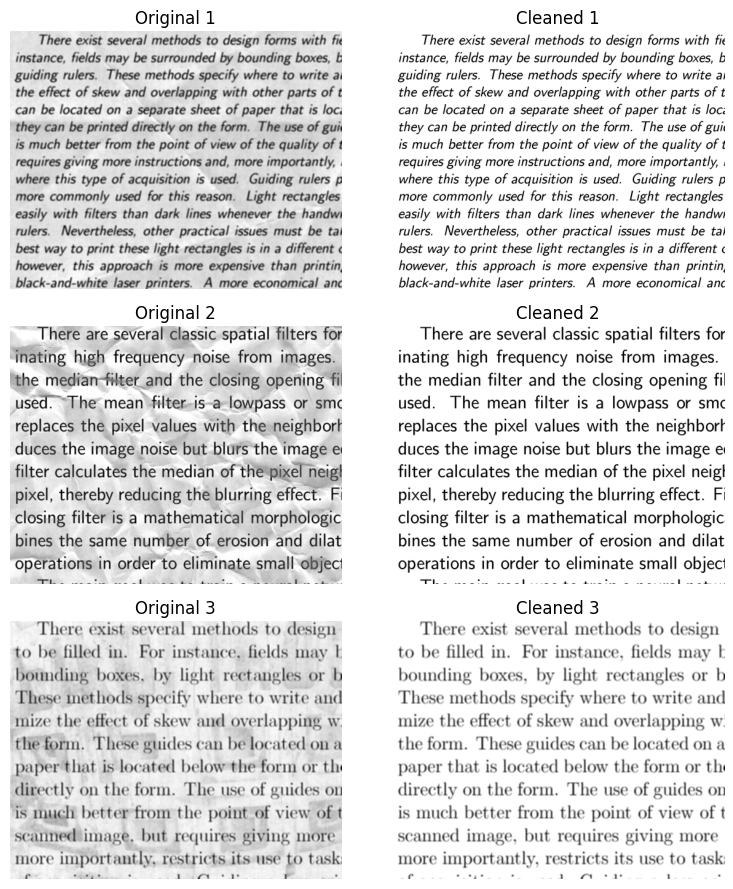

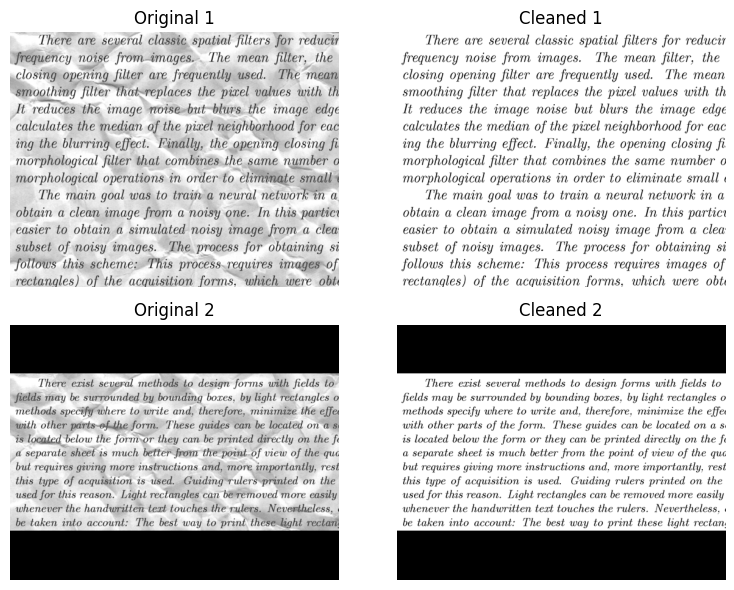

In [16]:
def visualize_paired_dataset(paired_loader, num_images=5):
    for train_images, cleaned_images in paired_loader:
        fig, axes = plt.subplots(num_images, 2, figsize=(8, num_images * 3))
        for i in range(num_images):
            axes[i, 0].imshow(
                train_images[i].permute(1, 2, 0).cpu().numpy(), cmap="gray"
            )
            axes[i, 0].set_title(f"Original {i+1}")
            axes[i, 0].axis("off")
            axes[i, 1].imshow(
                cleaned_images[i].permute(1, 2, 0).cpu().numpy(), cmap="gray"
            )
            axes[i, 1].set_title(f"Cleaned {i+1}")
            axes[i, 1].axis("off")
        plt.tight_layout()
        plt.show()
        break


visualize_paired_dataset(train_loader, num_images=3)
visualize_paired_dataset(val_loader, num_images=2)



In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")




cuda


In [18]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=1, bias=False),
            nn.Conv2d(1, 8, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(8, 8, kernel_size=3, stride=1, padding=1, bias=False),
            nn.Conv2d(8, 16, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=3, stride=1, padding=1, bias=False),
            nn.Conv2d(16, 32, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.enc4 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.Conv2d(32, 64, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.enc5 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.Conv2d(64, 128, kernel_size=1, stride=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.dec5 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=1, stride=1, bias=False),
            nn.ConvTranspose2d(
                64,
                64,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1,
                groups=64,
                bias=False,
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
        )
        self.dec4 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=1, stride=1, bias=False),
            nn.ConvTranspose2d(
                32,
                32,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1,
                groups=32,
                bias=False,
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(p=0.3),
        )
        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=1, stride=1, bias=False),
            nn.ConvTranspose2d(
                16,
                16,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1,
                groups=16,
                bias=False,
            ),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Dropout(p=0.2),
        )
        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(16, 8, kernel_size=1, stride=1, bias=False),
            nn.ConvTranspose2d(
                8,
                8,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1,
                groups=8,
                bias=False,
            ),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.Dropout(p=0.1),
        )
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(8, 1, kernel_size=1, stride=1, bias=False),
            nn.ConvTranspose2d(
                1,
                1,
                kernel_size=3,
                stride=2,
                padding=1,
                output_padding=1,
                groups=1,
                bias=False,
            ),
            nn.Sigmoid(),
        )
        self.conv4 = nn.Conv2d(64, 32, kernel_size=1, stride=1, bias=False)
        self.conv5 = nn.Conv2d(128, 64, kernel_size=1, stride=1, bias=False)

    def forward(self, x):
        enc1_out = self.enc1(x)
        enc2_out = self.enc2(enc1_out)
        enc3_out = self.enc3(enc2_out)
        enc4_out = self.enc4(enc3_out)
        enc5_out = self.enc5(enc4_out)

        dec5_out = self.dec5(enc5_out)
        dec5_out = F.interpolate(
            dec5_out, size=(26, 33), mode="bilinear", align_corners=False
        )
        dec5_out = torch.cat([dec5_out, enc4_out], dim=1)
        dec5_out = self.conv5(dec5_out)

        dec4_out = self.dec4(enc4_out)
        dec4_out = F.interpolate(
            dec4_out, size=(52, 67), mode="bilinear", align_corners=False
        )
        dec4_out = torch.cat([dec4_out, enc3_out], dim=1)
        dec4_out = self.conv4(dec4_out)

        dec3_out = self.dec3(dec4_out)
        dec3_out = F.interpolate(
            dec3_out, size=(105, 135), mode="bilinear", align_corners=False
        )

        dec2_out = self.dec2(dec3_out)
        dec2_out = F.interpolate(
            dec2_out, size=(210, 270), mode="bilinear", align_corners=False
        )

        dec1_out = self.dec1(dec2_out)
        dec1_out = F.interpolate(
            dec1_out, size=(420, 540), mode="bilinear", align_corners=False
        )

        outputs = torch.clamp(dec1_out, min=0.001, max=0.999)
        return outputs


model = DenoisingAutoencoder().to(device)



In [19]:
summary(model, input_size=(16, 1, 420, 540), device=device)




Layer (type:depth-idx)                   Output Shape              Param #
DenoisingAutoencoder                     [16, 1, 420, 540]         --
├─Sequential: 1-1                        [16, 8, 210, 270]         --
│    └─Conv2d: 2-1                       [16, 1, 420, 540]         9
│    └─Conv2d: 2-2                       [16, 8, 420, 540]         8
│    └─BatchNorm2d: 2-3                  [16, 8, 420, 540]         16
│    └─ReLU: 2-4                         [16, 8, 420, 540]         --
│    └─MaxPool2d: 2-5                    [16, 8, 210, 270]         --
├─Sequential: 1-2                        [16, 16, 105, 135]        --
│    └─Conv2d: 2-6                       [16, 8, 210, 270]         576
│    └─Conv2d: 2-7                       [16, 16, 210, 270]        128
│    └─BatchNorm2d: 2-8                  [16, 16, 210, 270]        32
│    └─ReLU: 2-9                         [16, 16, 210, 270]        --
│    └─Dropout: 2-10                     [16, 16, 210, 270]        --
│    └─MaxPool2

In [20]:
class RMSELoss(nn.Module):
    def __init__(self):
        super(RMSELoss, self).__init__()

    def forward(self, pred, target):
        return torch.sqrt(F.mse_loss(pred, target))




In [21]:
# Use pure RMSE loss (remove L1 component) to focus on the evaluation metric
class HybridLoss(nn.Module):
    def __init__(self, lambda_rmse=1.0, lambda_l1=0.0):
        super(HybridLoss, self).__init__()
        self.lambda_rmse = lambda_rmse
        self.lambda_l1 = lambda_l1
        self.rmse_loss = RMSELoss()
        self.l1_loss = nn.L1Loss()

    def forward(self, pred, target):
        return self.lambda_rmse * self.rmse_loss(
            pred, target
        ) + self.lambda_l1 * self.l1_loss(pred, target)




In [22]:
# Lower learning rate and remove weight decay for finer convergence
optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.0)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=6, verbose=True
)
criterion = HybridLoss(lambda_rmse=1.0, lambda_l1=0.0)  # pure RMSE



/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [23]:
epochs = 1000
patience = 120  # early‑stopping patience
early_stop_counter = 0
best_val_loss = float("inf")
best_model_state = None

epoch = 0
while epoch < epochs:
    model.train()
    train_loss = 0.0
    train_rmse_loss = 0.0
    rmse_metric = RMSELoss()  # single instance for this epoch
    for train_images, train_cleaned_images in train_loader:
        train_images = train_images.to(device, non_blocking=True)
        train_cleaned_images = train_cleaned_images.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(train_images)
        loss = criterion(outputs, train_cleaned_images)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_rmse_loss += rmse_metric(outputs, train_cleaned_images).item()
    train_loss /= len(train_loader)
    train_rmse_loss /= len(train_loader)
    print(
        f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, RMSE: {train_rmse_loss:.4f}"
    )

    model.eval()
    val_loss = 0.0
    val_rmse_loss = 0.0
    rmse_metric_val = RMSELoss()  # separate instance for validation
    with torch.no_grad():
        for val_images, val_cleaned_images in val_loader:
            val_images = val_images.to(device, non_blocking=True)
            val_cleaned_images = val_cleaned_images.to(device, non_blocking=True)
            outputs = model(val_images)
            loss = criterion(outputs, val_cleaned_images)
            val_loss += loss.item()
            val_rmse_loss += rmse_metric_val(outputs, val_cleaned_images).item()
    val_loss /= len(val_loader)
    val_rmse_loss /= len(val_loader)

    prev_lr = optimizer.param_groups[0]["lr"]
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]
    if current_lr != prev_lr:
        print(f"Learning Rate updated: {current_lr:.6f}\\n")

    if val_loss < best_val_loss:
        print(
            f"New best validation loss: {val_loss:.4f} (prev: {best_val_loss:.4f}), RMSE: {val_rmse_loss:.4f}"
        )
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        print(
            f"Validation loss increased! Early stopping: {early_stop_counter}/{patience}"
        )

    if early_stop_counter >= patience:
        print(f"Early stopping triggered after {epoch+1} epochs")
        model.load_state_dict(best_model_state)
        break

    epoch += 1

if best_model_state is not None:
    torch.save(best_model_state, "best_model.pth")
    print(f"Best model saved with val_loss = {best_val_loss:.4f}")
else:
    print("No best model was saved.")



Epoch [1/1000], Train Loss: 0.4434, RMSE: 0.4434
New best validation loss: 0.4770 (prev: inf), RMSE: 0.4770
Epoch [2/1000], Train Loss: 0.4399, RMSE: 0.4399
New best validation loss: 0.4770 (prev: 0.4770), RMSE: 0.4770
Epoch [3/1000], Train Loss: 0.4287, RMSE: 0.4287
Validation loss increased! Early stopping: 1/120
Epoch [4/1000], Train Loss: 0.4469, RMSE: 0.4469
Validation loss increased! Early stopping: 2/120
Epoch [5/1000], Train Loss: 0.4437, RMSE: 0.4437
Validation loss increased! Early stopping: 3/120
Epoch [6/1000], Train Loss: 0.4407, RMSE: 0.4407
Validation loss increased! Early stopping: 4/120
Epoch [7/1000], Train Loss: 0.4446, RMSE: 0.4446
Validation loss increased! Early stopping: 5/120
Epoch [8/1000], Train Loss: 0.4405, RMSE: 0.4405
Learning Rate updated: 0.000025\n
Validation loss increased! Early stopping: 6/120
Epoch [9/1000], Train Loss: 0.4391, RMSE: 0.4391
Validation loss increased! Early stopping: 7/120
Epoch [10/1000], Train Loss: 0.4508, RMSE: 0.4508
Validation 

In [24]:
best_model_path = "best_model.pth"
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model.eval()
    print("Loaded best model for inference.")
else:
    print("Best model file not found – inference will use the current model state.")




Loaded best model for inference.


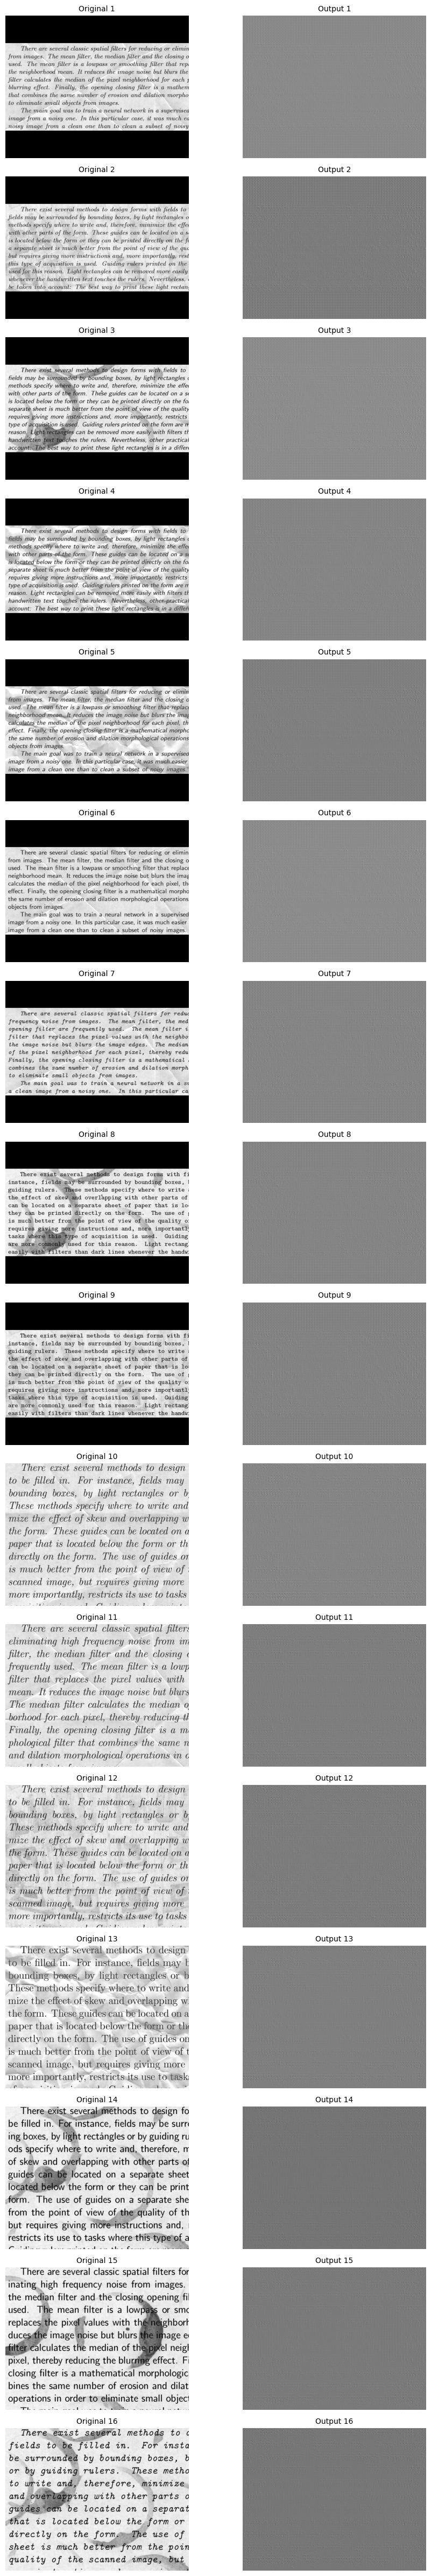

In [25]:
def visualize_images_and_outputs(images, outputs):
    num_images = images.size(0)
    fig, axes = plt.subplots(num_images, 2, figsize=(10, num_images * 3))
    for i in range(num_images):
        axes[i, 0].imshow(images[i].cpu().numpy().squeeze(), cmap="gray")
        axes[i, 0].set_title(f"Original {i + 1}", fontsize=10)
        axes[i, 0].axis("off")
        axes[i, 1].imshow(outputs[i].cpu().detach().numpy().squeeze(), cmap="gray")
        axes[i, 1].set_title(f"Output {i + 1}", fontsize=10)
        axes[i, 1].axis("off")
    plt.tight_layout()
    plt.show()


for batch in test_loader:
    batch = batch.to(device, non_blocking=True)
    preds = model(batch)
    visualize_images_and_outputs(batch, preds)
    break



In [26]:
print(f"Test directory: {test_dir}")



Test directory: /kaggle/input/denoising-dirty-documents/test


In [27]:
test_file_paths = sorted(
    [os.path.join(test_dir, f) for f in os.listdir(test_dir) if f.endswith(".png")],
    key=lambda x: int(os.path.splitext(os.path.basename(x))[0]),
)

model.eval()
all_outputs = []
with torch.no_grad():
    for batch in test_loader:  # batch inference instead of per‑image loop
        batch = batch.to(device, non_blocking=True)
        out_batch = model(batch).cpu()  # (B,1,420,540)
        all_outputs.append(out_batch)
all_outputs = torch.cat(all_outputs, dim=0)  # shape (N_test, 1, 420, 540)
print("all_outputs shape:", all_outputs.shape)



all_outputs shape: torch.Size([29, 1, 420, 540])


In [28]:
import csv

target_size = (420, 540)  # (height, width)


def compute_padding(orig_size, target_size):
    orig_h, orig_w = orig_size
    tgt_h, tgt_w = target_size
    pad_top = (tgt_h - orig_h) // 2 if tgt_h > orig_h else 0
    pad_bottom = (tgt_h - orig_h - pad_top) if tgt_h > orig_h else 0
    pad_left = (tgt_w - orig_w) // 2 if tgt_w > orig_w else 0
    pad_right = (tgt_w - orig_w - pad_left) if tgt_w > orig_w else 0
    return pad_top, pad_bottom, pad_left, pad_right


def remove_padding(pred, orig_size, target_size):
    orig_h, orig_w = orig_size
    pad_top, _, pad_left, _ = compute_padding(orig_size, target_size)
    return pred[:, pad_top : pad_top + orig_h, pad_left : pad_left + orig_w]


submission_data = []  # will hold tuples (id, value)

for idx, file_path in enumerate(test_file_paths):
    image_id = os.path.splitext(os.path.basename(file_path))[0]
    orig_img = Image.open(file_path).convert("L")
    orig_width, orig_height = orig_img.size
    orig_size = (orig_height, orig_width)

    pred = all_outputs[idx]  # (1, 420, 540)
    cropped_pred = remove_padding(pred, orig_size, target_size)  # (1, h, w)
    pred_np = cropped_pred.squeeze(0).cpu().numpy()

    ids = [
        f"{image_id}_{r+1}_{c+1}" for r in range(orig_height) for c in range(orig_width)
    ]
    values = pred_np.ravel().tolist()
    submission_data.extend(zip(ids, values))

submission_file = "/kaggle/working/submission.csv"
submission_df = pd.DataFrame(submission_data, columns=["id", "value"])
submission_df.to_csv(submission_file, index=False)

print(f"Submission file '{submission_file}' created.")

Submission file '/kaggle/working/submission.csv' created.
